In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as an
from reComBat import reComBat
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def plot(data,metadata,res=0.1,type='tsne',plot_mode='all',name=None,):
    adata = an.AnnData(X=data,obs=metadata)

    if plot_mode == 'all':
        to_colour_by = ['mouse','Genotype','Sex','Age','Lobule','CellType','Genotype_Sex','pc_number','ZeroHop']
    else:
        to_colour_by = [
                        'Zero-hop cluster'
                        ]

    if type == 'tsne':
        sc.tl.tsne(adata,use_rep='X')
        if name is not None:
            sc.pl.tsne(adata,color=to_colour_by,show=False,ncols=2,hspace=0.25,legend_fontsize=8,save='_'+name)
        else:
            sc.pl.tsne(adata,color=to_colour_by,show=True,ncols=2,hspace=0.25,legend_fontsize=8)
    
    elif type == 'umap':
        sc.pp.neighbors(adata,use_rep='X', random_state=0)
        sc.tl.umap(adata, random_state=0)
        if name is not None:
            sc.pl.umap(adata,color=to_colour_by,show=True,ncols=3,wspace=0.25, hspace=0.25,legend_fontsize=15,save='_'+name)
        else:
            sc.pl.umap(adata,color=to_colour_by,show=True,ncols=3,wspace=0.25,hspace=0.25,legend_fontsize=15)
    
    elif type == 'pca':
        sc.tl.pca(adata,use_highly_variable=False)
        if name is not None:
            sc.pl.pca(adata,color=to_colour_by,show=True,ncols=2,hspace=0.25,legend_fontsize=15,save='_'+name)
        else:
            sc.pl.pca(adata,color=to_colour_by,show=True,ncols=2,hspace=0.25,legend_fontsize=15)
    
    elif type == 'leiden':
        sc.pp.neighbors(adata,use_rep='X')
        sc.tl.leiden(adata, resolution=res, key_added="leiden")
        sc.tl.umap(adata, random_state=0)
        sc.pl.umap(adata, color=["leiden","Genotype","CellType"], wspace=0.25,hspace=0.25,legend_fontsize=15,save='_'+name)
        #sc.pl.umap(adata, color=["leiden","Genotype"], legend_loc="on data", frameon=False,wspace=0.25,hspace=0.25,legend_fontsize=8)
    
    elif type == 'cluster':
        ct = pd.crosstab(adata.obs["leiden"], adata.obs["Genotype"])
        
        ct.plot(
            kind="bar",
            stacked=True,
            figsize=(6, 4)
        )
        
        plt.xlabel("Leiden cluster")
        plt.ylabel("Number of cells")
        plt.legend(title="Genotype")
        plt.tight_layout()
        plt.show()
    return adata;

In [17]:
data_path = '.'
data      = pd.read_csv(os.path.join(data_path,'Lib_SN10_0216-790norm-t.csv'),index_col=0)
metadata  = pd.read_csv(os.path.join(data_path,'mouse 4_9wk_cluster_metadata_251222.csv'),index_col=0)

In [18]:
data

,652.28,653.28,654.27,655.28,656.29,657.3,664.44,669.28,670.27,671.28,...,1502.1,1521.99,1523.07,1524.01,1525.08,1544.91,1545.91,1546.92,1573.01,1574.02
4wk_Mut_F_3158_IV_GC1,2.214884,4.584748,1.087412,1.247671,5.939946,3.490971,5.205980,1.081581,3.158221,4.484538,...,0.881334,0.602903,0.516525,0.741726,0.979938,1.041641,1.256828,1.170048,0.683590,0.682986
4wk_Mut_F_3158_IV_GC10,1.196504,1.718253,1.409254,2.202088,2.114120,0.920613,2.934361,1.280388,1.328978,1.414620,...,0.298038,0.542194,0.751139,0.455822,0.338143,0.444261,0.874864,0.493169,0.548611,0.530993
4wk_Mut_F_3158_IV_GC11,0.145681,0.124929,0.099383,0.091900,0.108660,0.089198,0.259634,0.063847,0.142923,0.110295,...,0.024778,0.074711,0.052201,0.030096,0.033655,0.031664,0.050981,0.049124,0.041648,0.022820
4wk_Mut_F_3158_IV_GC12,0.205982,0.398288,0.353399,0.494050,0.351632,0.302354,0.411597,0.215029,0.189112,0.227884,...,0.071570,0.101212,0.066043,0.044021,0.059567,0.070888,0.067609,0.079122,0.076919,0.093347
4wk_Mut_F_3158_IV_GC13,0.169102,0.370862,0.294474,0.351006,0.403048,0.352897,0.488709,0.159541,0.257964,0.278800,...,0.046508,0.053858,0.063179,0.037026,0.056895,0.043819,0.036980,0.082626,0.070722,0.071128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9wk_WT_M_2984_X_PC_Zpos5,0.273029,0.453706,0.527402,0.095820,0.514167,0.562754,0.116489,0.455358,0.518004,0.531300,...,0.092843,0.119399,0.062934,0.105856,0.101183,0.067138,0.083523,0.090522,0.152552,0.168319
9wk_WT_M_2984_X_PC_Zpos6,2.507165,4.261532,4.857615,0.859258,4.186407,4.575234,0.929490,3.473346,0.929841,4.577694,...,0.825871,0.853006,0.699023,1.207526,0.891709,0.678457,0.909598,0.834571,1.975359,1.307544
9wk_WT_M_2984_X_PC_Zpos7,0.249991,0.410112,0.456179,0.570463,0.080998,0.090641,0.101695,0.087395,0.408878,0.444638,...,0.055822,0.087111,0.106415,0.116201,0.055366,0.057223,0.063045,0.078234,0.047212,0.098107
9wk_WT_M_2984_X_PC_Zpos8,2.106168,3.616678,4.270122,5.052017,4.272288,3.861036,0.955201,3.481974,4.038123,4.832481,...,0.861657,0.545041,0.518119,0.612942,0.886162,2.563447,2.182197,1.494220,0.530890,0.465104


In [31]:
metadata.ZeroHop = metadata.ZeroHop.astype(str)
metadata.Age = metadata.Age.astype(str)
metadata.pc_number = metadata.pc_number.astype(str)
metadata_coarse  = metadata[['mouse','Genotype','Sex', 'Genotype_Sex','Age','Lobule','CellType','pc_number','ZeroHop']]
metadata_coarse = metadata_coarse.fillna('None')
valid_ids = list(set(data.index).intersection(set(metadata_coarse.index)))
valid_ids.sort()
data_fit = data.loc[valid_ids]
metadata_fit = metadata_coarse.loc[valid_ids]
assert np.array(data_fit.index == metadata_fit.index).all()

In [32]:
metadata_coarse;

In [ ]:
select = (
 (metadata_coarse['Age'] == '9') & (metadata_coarse['CellType'] != 'GC') & (metadata_coarse['Lobule'] == 'X')
)
metadata_subset = metadata_coarse[select]
metadata_subset
valid_ids = list(set(data.index).intersection(set(metadata_subset.index)))
valid_ids.sort()
data_fit = data.loc[valid_ids]
metadata_fit = metadata_coarse.loc[valid_ids]
assert np.array(data_fit.index == metadata_fit.index).all()

In [35]:
metadata_fit

,mouse,Genotype,Sex,Genotype_Sex,Age,Lobule,CellType,pc_number,ZeroHop
sample,,,,,,,,,
9wk_Mut_F_2965_X_PC_Zpos1,9wk_Mut_F_2965,Mut,F,Mut_F,9,X,PC_Zpos,1,5
9wk_Mut_F_2965_X_PC_Zpos10,9wk_Mut_F_2965,Mut,F,Mut_F,9,X,PC_Zpos,10,5
9wk_Mut_F_2965_X_PC_Zpos11,9wk_Mut_F_2965,Mut,F,Mut_F,9,X,PC_Zpos,11,5
9wk_Mut_F_2965_X_PC_Zpos12,9wk_Mut_F_2965,Mut,F,Mut_F,9,X,PC_Zpos,12,5
9wk_Mut_F_2965_X_PC_Zpos13,9wk_Mut_F_2965,Mut,F,Mut_F,9,X,PC_Zpos,13,5
...,...,...,...,...,...,...,...,...,...
9wk_WT_M_2984_X_PC_Zpos5,9wk_WT_M_2984,WT,M,WT_M,9,X,PC_Zpos,5,9
9wk_WT_M_2984_X_PC_Zpos6,9wk_WT_M_2984,WT,M,WT_M,9,X,PC_Zpos,6,9
9wk_WT_M_2984_X_PC_Zpos7,9wk_WT_M_2984,WT,M,WT_M,9,X,PC_Zpos,7,9


In [24]:
#plot non-batch-corrected data
# plot(data_fit,metadata_fit,0.2,type='umap');

In [36]:
model = reComBat(parametric=True,            # use parametric or non-parametric empirical Bayes method. 
                                             # The parametric method is significantly faster, whereas the 
                                             # non-parametric method is more flexible.
                 model='ridge',              # The regression model to be used. 
                                             # In our experience pure ridge regression performs best for singular design matrices 
                                             # and pure linear regression is best for non=singular matrices.
                 config={'alpha':1e-9},      # Optional arguments for the regression model. 
                                             # We tend to use a tiny regularisation parameter. 
                                             # This has also been cnfirmed by CV.
                 conv_criterion=1e-4,        # The convergence criterion for the empirical Bayes optimisation.
                                             # This value works well in practise.
                 max_iter=1000,              # The maximum number of iterations to stop if convergence is not reached.
                                             # This may also be useful for smaller convergence criteria.
                 n_jobs=1,                   # This parameter is only useful in non-parametric optimisation.
                                             # The non-parametric optimisation is very slow, but can be parallelised easily.
                                             # Set this to the number of CPUs on your machine for significant speed ups.
                 mean_only=False,            # Adjust the mean of your data only (not the variance).
                                             # This can be useful for single sample batches (where the variance is infinite)
                 optimize_params=True,       # If False no empirical Bayes optimisation is performed.
                 reference_batch=None,       # If a reference batch is present (e.g. a batch which is considered "batch effect free")
                                             # it can be set such that all data is adjuste dwith respect to this reference batch.
                 verbose=True                # Turn log messages on or off
                )

In [55]:
#'mouse','Genotype','Sex','Age','Lobule','CellType','Genotype_Sex','pc_number','ZeroHop'
model.fit(data_fit,metadata_fit.ZeroHop,X=metadata_fit.drop(['mouse','Sex','Age','Lobule','CellType','Genotype_Sex','pc_number','ZeroHop'],axis=1))
# model.fit(data_fit,metadata_fit.ZeroHop,X=mettadata_fit.drop(['mouse','Sex','Age','Lobule','Genotype_Sex','pc_number','ZeroHop'],axis=1))
#model.fit(data_fit,metadata_fit.ZeroHop,X=metadata_fit.drop(['mouse','Genotype','Sex','Age','Lobule','Genotype_Sex','pc_number','ZeroHop'],axis=1))
#model.fit(data_fit,metadata_fit.ZeroHop,X=metadata_fit.drop(['Genotype_Sex','pc_number','ZeroHop'],axis=1))
#model.fit(data_fit,metadata_fit.ZeroHop)

[reComBat] 2026-07-07 12:54:06,272 Starting to fot reComBat.
[reComBat] 2026-07-07 12:54:06,277 Fit the linear model.
[reComBat] 2026-07-07 12:54:06,298 Starting the empirical parametric optimisation.
[reComBat] 2026-07-07 12:54:06,301 Optimisation finished.
[reComBat] 2026-07-07 12:54:06,302 reComBat is fitted.


In [38]:
# Apply the recombat model
data_combat = model.transform(data_fit,metadata_fit.ZeroHop,X=metadata_fit.drop(['mouse','Sex','Age','Lobule','CellType','Genotype_Sex','pc_number','ZeroHop'],axis=1))
# data_combat = model.transform(data_fit,metadata_fit.ZeroHop,X=metadata_fit.drop(['mouse','Sex','Age','Lobule','Genotype_Sex','pc_number','ZeroHop'],axis=1))
#data_combat = model.transform(data_fit,metadata_fit.ZeroHop,X=metadata_fit.drop(['mouse','Genotype','Sex','Age','Lobule','Genotype_Sex','pc_number','ZeroHop'],axis=1))
#data_combat = model.transform(data_fit,metadata_fit.ZeroHop,X=metadata_fit.drop(['Genotype_Sex','pc_number','ZeroHop'],axis=1))
#data_combat = model.transform(data_fit,metadata_fit.ZeroHop)

[reComBat] 2026-07-07 12:12:59,481 Starting to transform.
[reComBat] 2026-07-07 12:12:59,487 Transform finished.


... storing 'mouse' as categorical
... storing 'Genotype' as categorical
... storing 'Sex' as categorical
... storing 'Genotype_Sex' as categorical
... storing 'Age' as categorical
... storing 'Lobule' as categorical
... storing 'CellType' as categorical
... storing 'pc_number' as categorical
... storing 'ZeroHop' as categorical


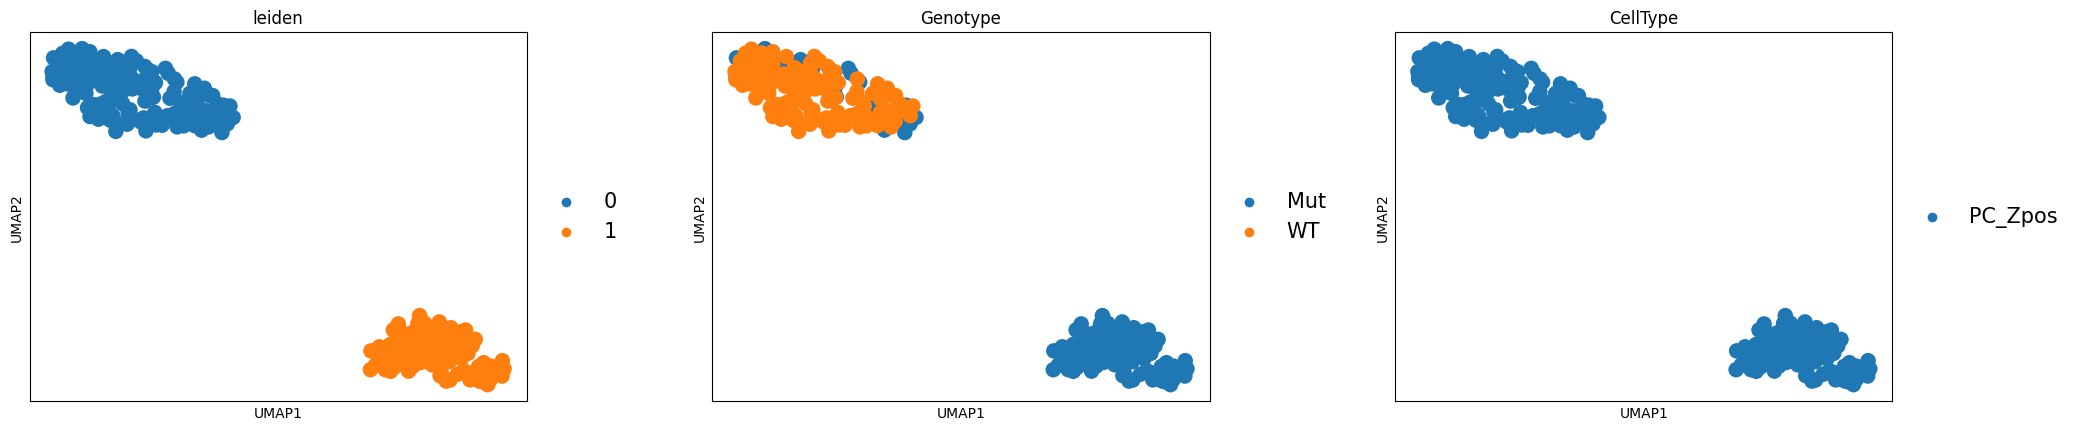

In [51]:
adata = plot(data_combat, metadata_fit, 0.1, type='leiden', name = 'test.svg')
adata.var_names;

Excluded


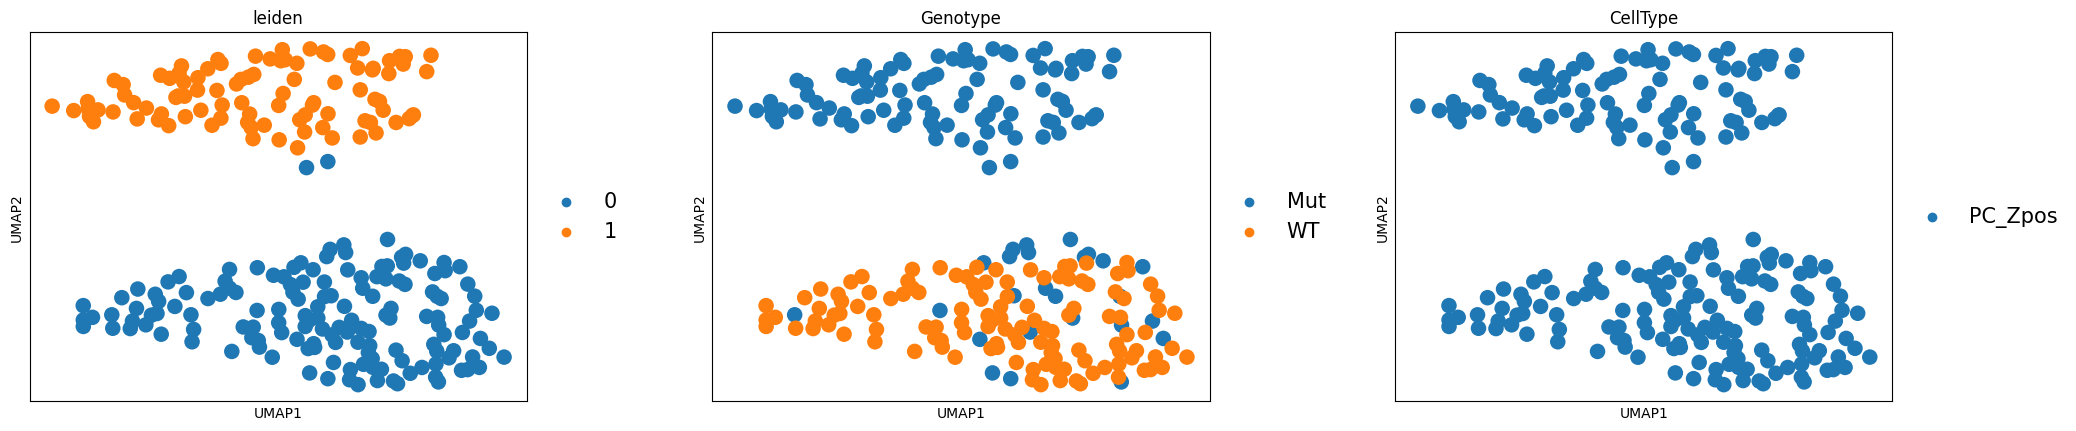

In [40]:
exclude = ["1545.91", "886.56", "1383.92","1384.99","1092.71","1093.72","716.58","958.64","1117.7","1116.72","1546.92","1501.07",
           "858.58","674.5","675.51","671.28","673.51","887.57","1498.99","837.58","779.51","877.78","1472.03","879.59","889.62","891.62",
          "864.62","851.75","809.55","795.56","824.72","807.54","833.54","863.61","905.62","907.62","819.54","822.54","747.54","745.57"]

adata = adata[:, ~adata.var_names.isin(exclude)].copy()

# check peaks
if not adata.var_names.isin(exclude).any():
    print("Excluded")

sc.pp.neighbors(adata,use_rep='X')
sc.tl.leiden(adata, resolution=0.1, key_added="leiden")
sc.tl.umap(adata, random_state=0)
sc.pl.umap(adata, color=["leiden","Genotype","CellType"], wspace=0.25,hspace=0.25,legend_fontsize=15)

# import pandas as pd

# df = pd.DataFrame(
#     adata.X,
#     index=adata.obs_names,
#     columns=adata.var_names
# )

# df.head()

In [570]:
# Export source data for graph
umap_coords = adata.obsm['X_umap']
print(umap_coords.shape)


# Combine UMAP coordinates and metadata
df = pd.DataFrame(4edx
    umap_coords, 
    columns=['UMAP1','UMAP2'],
    index=adata.obs_names
)

# Add metadata
df = pd.concat([df, adata.obs[['mouse','Genotype','Sex','Age','Lobule','CellType','leiden']]], axis=1)

# Preview
df.head()
df.to_csv('FigSxx.csv')


(240, 2)


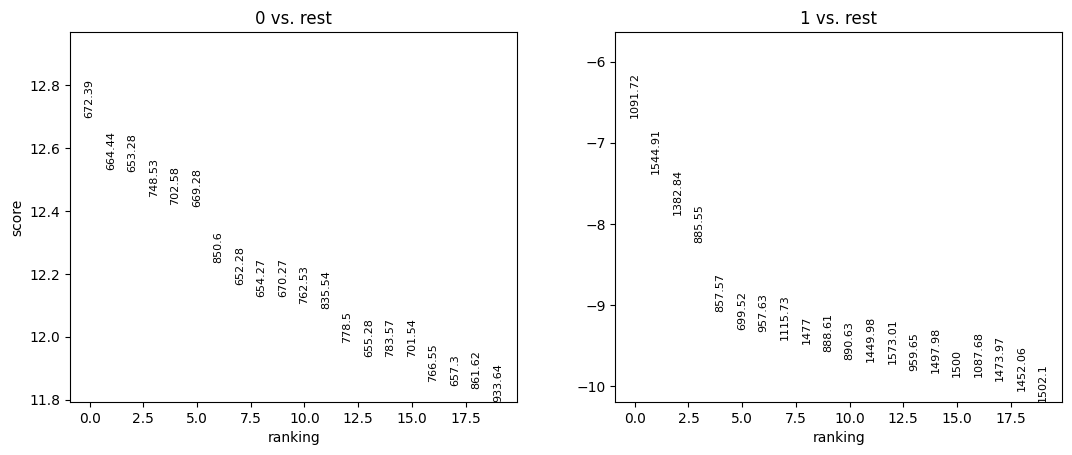

In [41]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False) #plot top 20 lipids in each cluster vs the rest of the cells

#Export to source data
# get all results
df = sc.get.rank_genes_groups_df(adata, group=None)

# keep top 20 per cluster
df_top20 = df.groupby("group").head(20).copy()

# add rank (1–20 within each cluster)
df_top20["rank"] = df_top20.groupby("group").cumcount() +  1

# reorder columns (optional, cleaner)
df_top20 = df_top20[[
    "group", "rank", "scores", "names",
    "logfoldchanges", "pvals", "pvals_adj"
]]

# save
# df_top20.to_csv("FigSxxx.csv", index=False)